In [1]:
import os
import random
import time
import logging
import requests
import pandas as pd
import numpy as np
import plotly.express as px
import folium
import xlsxwriter
import csv
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from concurrent.futures import ThreadPoolExecutor, as_completed
from dotenv import load_dotenv
import xlsxwriter

In [2]:
##Сбор ИНН по ОКВЭД

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

TARGET_OKVED = "41.20"
MAX_PAGES = 500

session = requests.Session()
retry = Retry(total=3, backoff_factor=0.5, status_forcelist=[429, 500, 502, 503, 504])
adapter = HTTPAdapter(max_retries=retry, pool_connections=10, pool_maxsize=10)
session.mount("https://", adapter)

def fetch_single_page(page, okved):
    url = "https://bo.nalog.gov.ru/advanced-search/organizations"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
        "Accept": "application/json, text/plain, */*",
        "Referer": "https://bo.nalog.gov.ru/search"
    }
    params = {
        "allFieldsMatch": "false",
        "okved": okved,
        "page": page,
        "size": 20
    }
    
    try:
        response = session.get(url, params=params, headers=headers, timeout=10)
        
        if response.status_code != 200:
            logging.error(f"Ошибка {response.status_code} на странице {page + 1}")
            return []
            
        data = response.json()
        companies = data.get('content', [])
        
        page_data = []
        for org in companies:
            inn = org.get('inn')
            name = org.get('shortName') or org.get('fullName')
            org_id = org.get('id')
            
            if inn and org_id:
                page_data.append({'inn': inn, 'name': name, 'org_id': org_id})
                
        logging.info(f"Страница {page + 1} обработана (найдено: {len(page_data)})")
        return page_data
        
    except Exception as e:
        logging.error(f"Ошибка на странице {page + 1}: {e}")
        return []

def get_all_inns_fast(okved, max_pages):
    all_data = []
    
    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = [executor.submit(fetch_single_page, page, okved) for page in range(max_pages)]
        
        for future in as_completed(futures):
            result = future.result()
            if result:
                all_data.extend(result)
                
    return all_data

if __name__ == "__main__":
    inns_result = get_all_inns_fast(okved=TARGET_OKVED, max_pages=MAX_PAGES)
    filename = f"inns.csv"
    
    try:
        if inns_result:
            with open(filename, mode="w", encoding="utf-8-sig", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=['inn', 'name', 'org_id'], delimiter=';')
                writer.writeheader()
                writer.writerows(inns_result)
                
            logging.info("Готово!")
            logging.info(f"Всего собрано записей: {len(inns_result)}")
            logging.info(f"Результаты сохранены в файл: {filename}")
        else:
            logging.warning("Данные не собраны. Возможно, по этому ОКВЭД ничего нет.")
    except Exception as e:
        logging.error(f"Ошибка при записи файла: {e}")

2026-07-01 16:56:50,245 | INFO | Страница 1 обработана (найдено: 20)
2026-07-01 16:56:50,258 | INFO | Страница 4 обработана (найдено: 20)
2026-07-01 16:56:50,266 | INFO | Страница 5 обработана (найдено: 20)
2026-07-01 16:56:50,271 | INFO | Страница 3 обработана (найдено: 20)
2026-07-01 16:56:50,279 | INFO | Страница 2 обработана (найдено: 20)
2026-07-01 16:56:50,321 | INFO | Страница 6 обработана (найдено: 20)
2026-07-01 16:56:50,334 | INFO | Страница 7 обработана (найдено: 20)
2026-07-01 16:56:50,336 | INFO | Страница 8 обработана (найдено: 20)
2026-07-01 16:56:50,345 | INFO | Страница 9 обработана (найдено: 20)
2026-07-01 16:56:50,383 | INFO | Страница 10 обработана (найдено: 20)
2026-07-01 16:56:50,389 | INFO | Страница 11 обработана (найдено: 20)
2026-07-01 16:56:50,406 | INFO | Страница 13 обработана (найдено: 20)
2026-07-01 16:56:50,407 | INFO | Страница 12 обработана (найдено: 20)
2026-07-01 16:56:50,416 | INFO | Страница 14 обработана (найдено: 20)
2026-07-01 16:56:50,466 | INF

In [3]:
# Сбор данных по ИНН
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")


LIMIT_COMPANIES = 10000

session = requests.Session()
retry = Retry(total=3, backoff_factor=0.5, status_forcelist=[429, 500, 502, 503, 504])
adapter = HTTPAdapter(max_retries=retry, pool_connections=10, pool_maxsize=10)
session.mount("https://", adapter)

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://bo.nalog.gov.ru/search" 
}

def process_single_company(comp):
    inn = comp['inn']
    name = comp['name']
    org_id = comp.get('org_id') 
    company_results = []
    
    if not org_id:
        logging.warning(f"ИНН {inn}: Пропущен (нет org_id в базе)")
        return company_results
    
    try:
        bfo_url = f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo/"
        bfo_res = session.get(bfo_url, headers=HEADERS, timeout=10).json()
        
        if not isinstance(bfo_res, list):
            return company_results
            
        for report in bfo_res:
            year = report.get('period')
            corrections = report.get("typeCorrections", [])
            
            if not corrections:
                continue
                
            fin_res = corrections[0].get("correction", {}).get("financialResult", {})
            if not fin_res:
                continue
            
            vr = fin_res.get("current2110", 0)   
            st = fin_res.get("current2120", 0)   
            np = fin_res.get("current2410", 0)   
            pr = fin_res.get("current2330", 0)   
            
            ebitda = vr - st + np + pr
            
            if vr != 0 or st != 0:
                company_results.append({
                    'inn': inn,
                    'name': name,
                    'year': year,
                    'Вр_2110': vr,
                    'СТ_2120': st,
                    'НП_2410': np,
                    'Пр_2330': pr,
                    'EBITDA': ebitda
                })
        
        if company_results:
            logging.info(f"ИНН {inn}: Данные собраны")
        else:
            logging.warning(f"ИНН {inn}: Нет нужных финансовых данных")
            
    except Exception as e:
        logging.error(f"ИНН {inn}: Ошибка обработки - {e}")
        
    return company_results

def run_turbo_parser(input_filename="inns.csv", output_filename="ebitda_results_final.csv"):
    companies = []
    try:
        with open(input_filename, mode="r", encoding="utf-8-sig") as f:
            reader = csv.DictReader(f, delimiter=';')
            for row in reader:
                companies.append(row)
    except FileNotFoundError:
        logging.error(f"Файл {input_filename} не найден.")
        return

    total_companies = len(companies)
    if total_companies == 0:
        logging.error("Файл с ИНН пуст.")
        return
        
    random_companies = random.sample(companies, min(LIMIT_COMPANIES, total_companies))
    all_results = []
    
    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = [executor.submit(process_single_company, comp) for comp in random_companies]
        
        for future in as_completed(futures):
            result = future.result()
            if result:
                all_results.extend(result)

    if all_results:
        with open(output_filename, mode="w", encoding="utf-8-sig", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=['inn', 'name', 'year', 'Вр_2110', 'СТ_2120', 'НП_2410', 'Пр_2330', 'EBITDA'], delimiter=';')
            writer.writeheader()
            writer.writerows(all_results)
        logging.info("Готово!")
        logging.info(f"Собрано {len(all_results)} финансовых записей. Файл: {output_filename}")
    else:
        logging.warning("Данные не собраны.")

if __name__ == "__main__":
    run_turbo_parser()

2026-07-01 16:57:08,548 | INFO | ИНН 2130178214: Данные собраны
2026-07-01 16:57:08,552 | WARNING | ИНН 9201505590: Нет нужных финансовых данных
2026-07-01 16:57:08,554 | WARNING | ИНН 9705195002: Нет нужных финансовых данных
2026-07-01 16:57:08,570 | WARNING | ИНН 5610151627: Нет нужных финансовых данных
2026-07-01 16:57:08,577 | INFO | ИНН 5405492712: Данные собраны
2026-07-01 16:57:08,604 | WARNING | ИНН 7751329200: Нет нужных финансовых данных
2026-07-01 16:57:08,604 | INFO | ИНН 7716847898: Данные собраны
2026-07-01 16:57:08,605 | WARNING | ИНН 6829147670: Нет нужных финансовых данных
2026-07-01 16:57:08,627 | WARNING | ИНН 7705317948: Нет нужных финансовых данных
2026-07-01 16:57:08,632 | INFO | ИНН 5190400500: Данные собраны
2026-07-01 16:57:08,660 | INFO | ИНН 7724414961: Данные собраны
2026-07-01 16:57:08,668 | INFO | ИНН 9111016468: Данные собраны
2026-07-01 16:57:08,674 | INFO | ИНН 1101170113: Данные собраны
2026-07-01 16:57:08,676 | INFO | ИНН 9723154094: Данные собраны
20

In [ ]:
# ЭКСПОРТ СЫРЫХ ДАННЫХ ДЛЯ EXCEL

YEAR_PAST = 2021
YEAR_CURRENT = 2024

df = pd.read_csv('ebitda_results_final.csv', delimiter=';')

export_df = df[['inn', 'name', 'year', 'Вр_2110', 'EBITDA']].copy()

# Фильтруем только нужные нам годы (чтобы не тащить мусор)
export_df = export_df[export_df['year'].isin([YEAR_PAST, YEAR_CURRENT])]

# Переименовываем колонку выручки для чистоты
export_df = export_df.rename(columns={'Вр_2110': 'Revenue'})

# Сохраняем в длинном (Long) формате
export_filename = 'Raw_Financial_Data_Longnew1.xlsx'
export_df.to_excel(export_filename, index=False)

print(f"Сырые нормализованные данные выгружены в {export_filename}")
print("Готово для загрузки в модель данных Excel.")

In [4]:
# Бизнес сводка по отрасли
YEAR_PAST = 2021
YEAR_CURRENT = 2024

df = pd.read_csv('ebitda_results_final.csv', delimiter=';')

df_current = df[df['year'] == YEAR_CURRENT][['inn', 'name', 'EBITDA', 'Вр_2110']].rename(
    columns={'EBITDA': 'EBITDA_current', 'Вр_2110': 'Revenue_current'}
)
df_past = df[df['year'] == YEAR_PAST][['inn', 'EBITDA']].rename(
    columns={'EBITDA': 'EBITDA_past'}
)

merged_df = pd.merge(df_current, df_past, on='inn', how='inner')

merged_df = merged_df[(merged_df['Revenue_current'] > 0) & (merged_df['EBITDA_past'] != 0)].copy()

merged_df['Growth_Percent'] = ((merged_df['EBITDA_current'] - merged_df['EBITDA_past']) / merged_df['EBITDA_past'].abs()) * 100
merged_df['Growth_Percent'] = merged_df['Growth_Percent'].round().astype(int)

merged_df['EBITDA_Margin_%'] = (merged_df['EBITDA_current'] / merged_df['Revenue_current']) * 100
merged_df['EBITDA_Margin_%'] = merged_df['EBITDA_Margin_%'].round(2)

median_growth = merged_df['Growth_Percent'].median()
median_margin = merged_df['EBITDA_Margin_%'].median()

print("--- БИЗНЕС-СВОДКА ПО ОТРАСЛИ ---")
print(f"Медианный рост EBITDA: {median_growth}%")
print(f"Медианная рентабельность (EBITDA Margin): {median_margin}%")

print(" Топ-50 самых рентабельных компаний:")
top_margin = merged_df.sort_values(by='EBITDA_Margin_%', ascending=False).head(50)

top_margin = top_margin.reset_index(drop=True)
top_margin.index = top_margin.index + 1 
# ==========================================

display(top_margin[['name', 'Revenue_current', 'EBITDA_current', 'EBITDA_Margin_%']])

--- БИЗНЕС-СВОДКА ПО ОТРАСЛИ ---
Медианный рост EBITDA: -8.0%
Медианная рентабельность (EBITDA Margin): 3.55%
 Топ-50 самых рентабельных компаний:


,name,Revenue_current,EBITDA_current,EBITDA_Margin_%
1,"АО ""ЭСТЕЙТОФИС""",88.0,2768.0,3145.45
2,"ООО ""ВОСТОК АЭРО СЕРВИС""",7.0,51.0,728.57
3,"ООО ""КРИОЛИТ""",29.0,113.0,389.66
4,"ООО ""КРИОЛИТ""",29.0,113.0,389.66
5,"ООО ""КРИОЛИТ""",29.0,113.0,389.66
6,"ООО ""КРИОЛИТ""",29.0,113.0,389.66
7,"ООО ""АЛЬЯНС""",1424.0,2240.0,157.30
8,"ООО ""ВЕКТОР-ПЛЮС""",347.0,414.0,119.31
9,"ООО ""ЭЛЬМАГРУПП""",4898.0,5352.0,109.27
10,"ООО ""КИД""",6922.0,7337.0,106.00


In [6]:
# ==========================================
# ЭКСПОРТ ЧИСТЫХ ДАННЫХ ДЛЯ EXCEL-ДАШБОРДА
# ==========================================

# Оставляем только нужные колонки и переименовываем их для удобства
final_df = merged_df[[
    'inn', 'name', 'Revenue_current', 'EBITDA_past', 'EBITDA_current', 
    'Growth_Percent', 'EBITDA_Margin_%'
]].copy()

final_df = final_df.rename(columns={
    'inn': 'ИНН',
    'name': 'Название компании',
    'Revenue_current': f'Выручка_{YEAR_CURRENT}',
    'EBITDA_past': f'EBITDA_{YEAR_PAST}',
    'EBITDA_current': f'EBITDA_{YEAR_CURRENT}',
    'Growth_Percent': 'Рост_EBITDA_%',
    'EBITDA_Margin_%': 'Рентабельность_%'
})

# Сортируем по выручке
final_df = final_df.sort_values(by=f'Выручка_{YEAR_CURRENT}', ascending=False)

# Выгружаем в чистый Excel-файл без форматирования (только данные)
export_filename = 'Raw_Financial_Data.xlsx'
final_df.to_excel(export_filename, index=False)

print(f"✅ База данных успешно сформирована и выгружена в {export_filename}")

✅ База данных успешно сформирована и выгружена в Raw_Financial_Data.xlsx


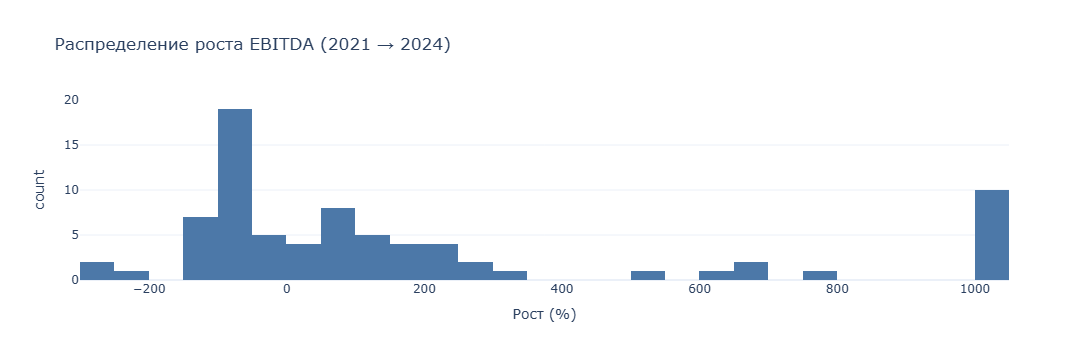

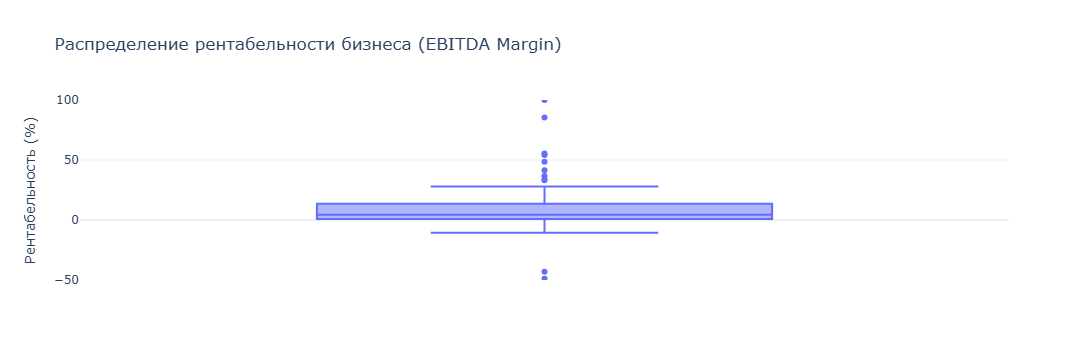

In [18]:
# Графики

merged_df['Growth_Clipped'] = np.clip(merged_df['Growth_Percent'], -300, 1000)

fig_hist = px.histogram(
    merged_df, 
    x='Growth_Clipped', 
    nbins=40,
    title=f'Распределение роста EBITDA ({YEAR_PAST} → {YEAR_CURRENT})',
    labels={'Growth_Clipped': 'Рост (%)', 'count': 'Кол-во компаний'},
    template='plotly_white',
    color_discrete_sequence=['#4C78A8']
)
fig_hist.show()

fig_box = px.box(
    merged_df, 
    y='EBITDA_Margin_%', 
    title='Распределение рентабельности бизнеса (EBITDA Margin)',
    template='plotly_white',
    labels={'EBITDA_Margin_%': 'Рентабельность (%)'}
)
fig_box.update_yaxes(range=[-50, 100])
fig_box.show()

In [19]:
#Топ компаний на карте

load_dotenv()

# Эта функция достает значение ключа по его имени
DADATA_API_KEY = os.getenv("DADATA_API_KEY")

# Проверка (необязательно, но полезно):
if DADATA_API_KEY is None:
    print("ВНИМАНИЕ: Ключ DADATA_API_KEY не найден. Убедитесь, что файл .env существует.")

def get_coords(inn):
    """Получает координаты компании по ИНН через DaData API"""
    url = "https://suggestions.dadata.ru/suggestions/api/4_1/rs/findById/party"
    headers = {
        "Content-Type": "application/json",
        "Accept": "application/json",
        "Authorization": f"Token {DADATA_API_KEY}"
    }
    try:
        res = requests.post(url, json={"query": str(inn)}, headers=headers, timeout=5).json()
        if res.get('suggestions'):
            addr = res['suggestions'][0].get('data', {}).get('address', {}).get('data', {})
            if addr and addr.get('geo_lat'):
                lon = addr.get('geo_lon') or addr.get('geo_geo_lon')
                return float(addr['geo_lat']), float(lon)
    except Exception:
        pass
    return None, None

top_50 = merged_df.sort_values(by='Revenue_current', ascending=False).head(50).copy()

coords = []
for inn in top_50['inn']:
    coords.append(get_coords(inn))
    time.sleep(0.1) 
    
top_50['lat'] = [c[0] for c in coords]
top_50['lon'] = [c[1] for c in coords]
top_50 = top_50.dropna(subset=['lat', 'lon'])

print(f" Найдено координат: {len(top_50)} из 50. ")

m = folium.Map(location=[55.7558, 37.6173], zoom_start=5, tiles='cartodbpositron')

for _, row in top_50.iterrows():
    color = 'green' if row['EBITDA_Margin_%'] >= median_margin else 'crimson'
    
    popup_html = f"""
    <div style="font-family: Arial; min-width: 200px;">
        <b>{row['name']}</b><br><hr>
        <b>Выручка:</b> {row['Revenue_current']:,.0f} руб.<br>
        <b>EBITDA Margin:</b> {row['EBITDA_Margin_%']}%<br>
        <b>Рост EBITDA:</b> {row['Growth_Percent']}%
    </div>
    """
    
    radius = max(5, np.log10(row['Revenue_current'] + 1) * 2) if row['Revenue_current'] > 0 else 5
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        popup=folium.Popup(popup_html, max_width=300),
        color=color, fill=True, fill_color=color, fill_opacity=0.7
    ).add_to(m)

display(m)

 Найдено координат: 44 из 50. 
